In [1]:
import pandas as pd                                               
from sklearn.model_selection import train_test_split                
from sklearn.tree import DecisionTreeClassifier, plot_tree          
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,                   
    f1_score, confusion_matrix, roc_auc_score
)
import matplotlib.pyplot as plt            

In [2]:
df = pd.read_csv("sample_sales_data_FEATURES.csv")   
avg_spend = df["total_spend"].mean()                                   
df["churned"] = (df["total_spend"] < avg_spend).astype(int)           

feature_cols = ["quantity", "category_avg_spend"]                     
X = df[feature_cols]                                                
y = df["churned"]                                                    

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,                              
    random_state=42,                                                  
    stratify=y                                                        
)

tree_model = DecisionTreeClassifier(
    max_depth=4,                                                      
    min_samples_leaf=5,                                                
    random_state=42                                                 
)
tree_model.fit(X_train, y_train)                                        

y_pred = tree_model.predict(X_test)                                
y_proba = tree_model.predict_proba(X_test)[:, 1]    

In [4]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

for feature, importance in zip(feature_cols, tree_model.feature_importances_):  
    print(f"{feature}: {importance:.4f}")                                      

Accuracy: 0.875
Precision: 0.8571428571428571
Recall: 1.0
F1 Score: 0.9230769230769231
ROC-AUC: 0.5833333333333334
Confusion Matrix:
 [[1 1]
 [0 6]]
quantity: 0.8821
category_avg_spend: 0.1179


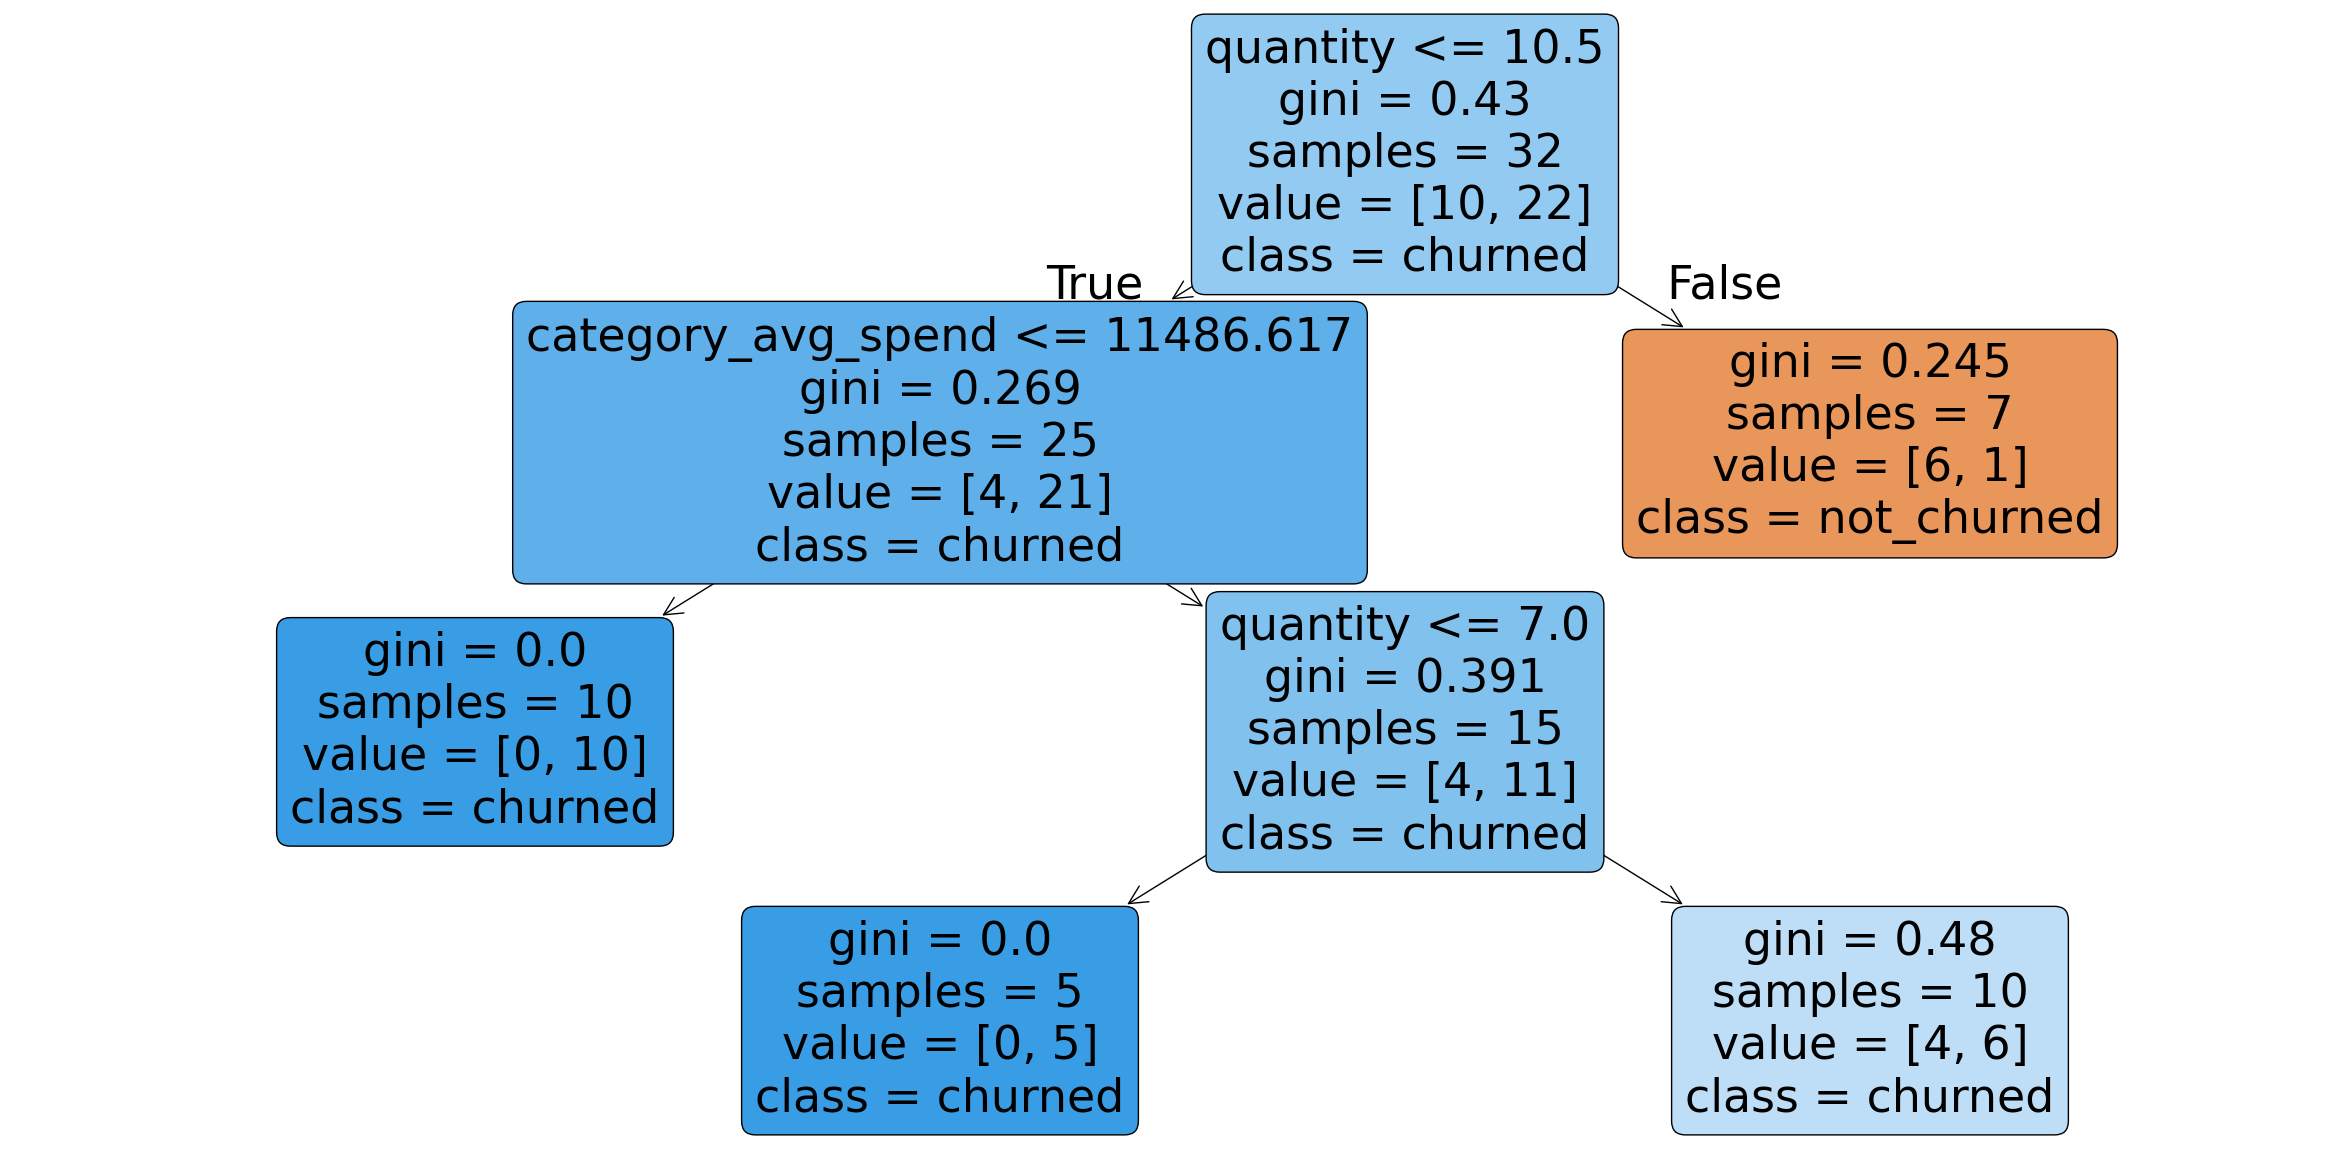

In [6]:
plt.figure(figsize=(30, 15))                                  
plot_tree(
    tree_model,                                                     
    feature_names=feature_cols,                                      
    class_names=["not_churned", "churned"],                             
    filled=True,                                                
    rounded=True                                                          
)
plt.show()       